In [126]:
import pandas as pd
import numpy as np

In [127]:
df=pd.read_csv('/content/student_data.csv')

In [128]:
df

,unknown,serial_no,cgpa,iq,placement
0,NaN,1,5.34,128,0
1,NaN,2,6.50,97,0
2,NaN,3,7.32,130,1
3,NaN,4,5.17,100,0
4,NaN,5,8.59,81,0
...,...,...,...,...,...
95,NaN,96,7.34,80,0
96,NaN,97,6.60,89,0
97,NaN,98,5.20,100,0
98,NaN,99,8.62,95,0


In [129]:
#it show over view of data set
df.head()

,unknown,serial_no,cgpa,iq,placement
0,NaN,1,5.34,128,0
1,NaN,2,6.50,97,0
2,NaN,3,7.32,130,1
3,NaN,4,5.17,100,0
4,NaN,5,8.59,81,0


In [130]:
#100 rows and 5 column
df.shape

(100, 5)

In [131]:
#Steps

#0. preprocess + EDA + Feature Slection
#1. Extract input and output cols
#2. Scale the values
#3. Train test split
#4. Train the model
#5. Evaluate the model/model selection
#6. Deploy the model

In [132]:
#step 0-> will preprocess which in this data remove only one crupt cloumn
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unknown    0 non-null      float64
 1   serial_no  100 non-null    int64  
 2   cgpa       100 non-null    float64
 3   iq         100 non-null    int64  
 4   placement  100 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 4.0 KB


In [133]:
#in pandas sare rows chahiye but 2 onward chahiye only
df=df.iloc[:,2:]


In [134]:
#data wahi hai only jo chahiye
df.head()


,cgpa,iq,placement
0,5.34,128,0
1,6.50,97,0
2,7.32,130,1
3,5.17,100,0
4,8.59,81,0


In [135]:
# for EDA to show
import matplotlib.pyplot as plt

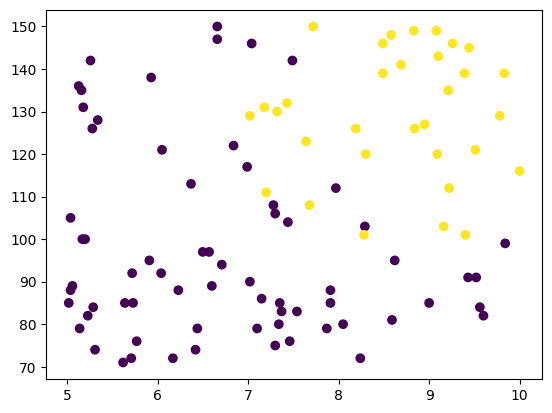

In [136]:
#on x axis and y axis graph and which placement done and not to (color them)
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [137]:
# our machine model is logistic regression (a algorithm which clasify the data into a line)

In [138]:
#Step 1 (Difrentiate input and output)
#indepent variable is input->(cgpa,iq)
#dependent varial is output->(placement)

In [139]:
#sare rows and coloumn 0 se 1 tk
x = df.iloc[:,0:2]
#sare rows chahiye and last column
y =df.iloc[:,-1]

In [140]:
x

,cgpa,iq
0,5.34,128
1,6.50,97
2,7.32,130
3,5.17,100
4,8.59,81
...,...,...
95,7.34,80
96,6.60,89
97,5.20,100
98,8.62,95


In [141]:
y

,placement
0,0
1,0
2,1
3,0
4,0
...,...
95,0
96,0
97,0
98,0


In [142]:
#1D tensor = vector hai ye
y.shape

(100,)

In [143]:
#2d tensor matrix hai ye
x.shape

(100, 2)

In [144]:
#step 3 train to split for how many data for train ex in my 100 student 10 to train
# basicaly test and train ko alag krde rahe X and y column se
from sklearn.model_selection import train_test_split

train_test_split(x,y,test_size=0.1)

[     cgpa   iq
 84   6.17   72
 17   5.28  126
 19   9.21  135
 88   5.23   82
 16   6.66  150
 ..    ...  ...
 61   9.56   84
 35  10.00  116
 65   5.71   72
 69   7.91   85
 28   9.51  121
 
 [90 rows x 2 columns],
     cgpa   iq
 7   7.20  111
 46  7.10   79
 47  5.13  136
 63  9.09  120
 60  5.02   85
 10  7.30   75
 57  9.08  149
 40  6.84  122
 78  6.44   79
 85  5.91   95,
 84    0
 17    0
 19    1
 88    0
 16    0
      ..
 61    0
 35    1
 65    0
 69    0
 28    1
 Name: placement, Length: 90, dtype: int64,
 7     1
 46    0
 47    0
 63    1
 60    0
 10    0
 57    1
 40    0
 78    0
 85    0
 Name: placement, dtype: int64]

In [145]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [146]:
#to check this are random 10 people to test similiar x_train 90 people
x_test

,cgpa,iq
6,8.19,126
92,6.42,74
42,7.68,108
37,8.05,80
67,6.66,147
80,7.02,129
77,7.87,79
81,5.18,131
73,9.60,82
30,7.64,123


In [147]:
y_test

,placement
6,1
92,0
42,1
37,0
67,0
80,1
77,0
81,0
73,0
30,1


In [148]:
x_train

,cgpa,iq
18,9.26,146
35,10.00,116
78,6.44,79
71,5.73,85
36,5.64,85
...,...,...
16,6.66,150
87,5.26,142
26,7.46,76
24,7.18,131


In [149]:
y_train

,placement
18,1
35,1
78,0
71,0
36,0
...,...
16,0
87,0
26,0
24,1


In [150]:
#step 2 for scalling
from sklearn.preprocessing import StandardScaler

In [151]:
scaler = StandardScaler()

In [152]:
x_train = scaler.fit_transform(x_train)

In [153]:
#now this all data between -1 to 1
x_train

array([[ 1.26910663e+00,  1.56966825e+00],
       [ 1.75852470e+00,  3.46197039e-01],
       [-5.95973060e-01, -1.16275079e+00],
       [-1.06554986e+00, -9.18056546e-01],
       [-1.12507368e+00, -9.18056546e-01],
       [ 6.34185883e-01,  5.09326534e-01],
       [ 1.24265160e+00,  1.83067544e-01],
       [-8.60523370e-01, -6.32579930e-01],
       [-7.34861973e-01, -7.95709425e-01],
       [ 1.38815427e+00,  1.52888588e+00],
       [-1.13830120e+00, -1.48900978e+00],
       [ 4.15931877e-01,  1.83067544e-01],
       [ 1.15005899e+00,  1.69201537e+00],
       [-5.56290514e-01, -4.28668061e-01],
       [-4.17401601e-01, -5.51015182e-01],
       [-1.26396259e-01, -8.77274172e-01],
       [-1.46237533e+00,  1.16184451e+00],
       [-1.59465048e-01, -1.16275079e+00],
       [ 1.15667275e+00,  5.09326534e-01],
       [-1.45576157e+00, -1.16275079e+00],
       [-6.42269364e-01,  2.23849918e-01],
       [ 6.27572125e-01, -1.83973819e-01],
       [-1.53512666e+00, -9.18056546e-01],
       [ 1.

In [154]:
x_test = scaler.transform(x_test)

In [155]:
x_test

array([[ 0.56143455,  0.75402078],
       [-0.60920058, -1.36666266],
       [ 0.2241329 ,  0.01993805],
       [ 0.46884194, -1.12196841],
       [-0.45047039,  1.61045062],
       [-0.21237511,  0.8763679 ],
       [ 0.3497943 , -1.16275079],
       [-1.42930654,  0.95793264],
       [ 1.49397439, -1.04040367],
       [ 0.19767787,  0.63167365]])

In [156]:
#4 to train the model (logistic regression)
from sklearn.linear_model import LogisticRegression

In [157]:
#to make an object
clf = LogisticRegression()

In [158]:
#now this has power to use logistic reggresion class ke under hai
#the fit function is used to train the model
clf.fit(x_train,y_train)


LogisticRegression()

In [159]:
#the model will train

In [160]:
#step 5 evaluate the model
clf.predict(x_test)
#ye hai model ka prediction test kr liye ab match kr lo original se sahi hai ya nahi
#ye predict kr ke output bata raha

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [161]:
# this is actual data output
#match kr lo output same hai ya diffrent hai
y_test


,placement
6,1
92,0
42,1
37,0
67,0
80,1
77,0
81,0
73,0
30,1


In [162]:
#isko variable e store kr liye hai
y_pred = clf.predict(x_test)


In [163]:
#now compare with code how accuracy is this

In [164]:
from sklearn.metrics import accuracy_score

In [165]:
accuracy_score(y_test,y_pred)

0.6

In [166]:
#means approx 90% give correct result

In [167]:
# to check which pattern notice ML to train them or ploting dession boundaries in 2D

In [168]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

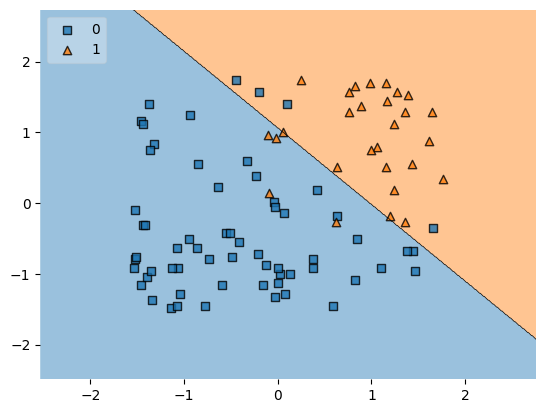

In [169]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [170]:
#step 6 to deploy the train model


In [171]:
#pickle kisi bhi object ko (python evrything is an object) convert into files
#now use files to use any environment

In [172]:
import pickle

In [173]:
#clf ko export krna hai isko ek file me convert krna hai name model.pkl and file open in write binary
pickle.dump(clf,open('model.pkl','wb'))

In [174]:
#check on folder file name is model.pkl this is model
#isko le jakr apni website me deploy kr lo

In [175]:
#platform for deploy
#1.AWS
#2.goole cloud platform(GCP)
#3. HEROKU
# We learn in future